## Ground Truth Generation

In [2]:
%pip install networkx graphviz numpy pgmpy torch matplotlib

Note: you may need to restart the kernel to use updated packages.


In [16]:
import random
import graphviz
import networkx as nx
import numpy as np
import os, time
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.parameter_estimator import DiscreteBayesianEstimator

import torch
import torch.nn as nn
import pandas as pd

from tqdm import tqdm
import matplotlib.pyplot as plt
import psutil

import logging
logging.getLogger("pgmpy").setLevel(logging.ERROR)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

import torch
print(torch.__version__)        # e.g. 2.8.0+cpu  vs  2.8.0+cu126
print(torch.version.cuda)       # None  => CPU-only build
print(torch.cuda.device_count())

cpu
2.14.0+cpu
None
0


### DAG Generation

In [4]:
#min in-degree?
'''
def generate_dag(n, max_in_degree, max_density, seed):

    # Random topological order
    rng = random.Random(seed)
    order = [f"X_{i}" for i in range(n)]
    rng.shuffle(order)

    # Create DAG
    G = nx.DiGraph()
    G.add_nodes_from(order)
    max_edges = round(max_density*n*(n-1)/2)

    # Feasibility Check
    ceiling = sum(min(i, max_in_degree) for i in range(n))
    if max_edges > ceiling:
        print(f"warning: density {max_density} needs {max_edges} edges, but max in-degree allows only {ceiling}")
        max_edges = ceiling
        max_density = max_edges / (n*(n-1)/2)

    # Backbone - Ensure weak connectivity
    for i in range(1, n):
        child = order[i]
        parent = rng.choice(order[:i])
        G.add_edge(parent, child)

    # Extra edges
    possible_edges = [(order[i], order[j]) for j in range(n) for i in range(j)]
    rng.shuffle(possible_edges)

    for u,v in possible_edges:
        if(G.has_edge(u,v)):
            continue
        if(G.number_of_edges() >= max_edges):
            break

        G.add_edge(u,v)
        if(G.number_of_edges() / (n*(n-1)/2) >= max_density):
            G.remove_edge(u,v)
            break

    return G
'''


'\ndef generate_dag(n, max_in_degree, max_density, seed):\n\n    # Random topological order\n    rng = random.Random(seed)\n    order = [f"X_{i}" for i in range(n)]\n    rng.shuffle(order)\n\n    # Create DAG\n    G = nx.DiGraph()\n    G.add_nodes_from(order)\n    max_edges = round(max_density*n*(n-1)/2)\n\n    # Feasibility Check\n    ceiling = sum(min(i, max_in_degree) for i in range(n))\n    if max_edges > ceiling:\n        print(f"warning: density {max_density} needs {max_edges} edges, but max in-degree allows only {ceiling}")\n        max_edges = ceiling\n        max_density = max_edges / (n*(n-1)/2)\n\n    # Backbone - Ensure weak connectivity\n    for i in range(1, n):\n        child = order[i]\n        parent = rng.choice(order[:i])\n        G.add_edge(parent, child)\n\n    # Extra edges\n    possible_edges = [(order[i], order[j]) for j in range(n) for i in range(j)]\n    rng.shuffle(possible_edges)\n\n    for u,v in possible_edges:\n        if(G.has_edge(u,v)):\n            co

In [5]:
def gen_dag_indegree(n, k, seed):
    rng = random.Random(seed)
    order = [f"X_{i}" for i in range(n)]
    rng.shuffle(order)
    G = nx.DiGraph()
    G.add_nodes_from(order)
    for i in range(1, n):
        n_parents = min(k, i)
        for p in rng.sample(order[:i], n_parents):
            G.add_edge(p, order[i])
    return G

def gen_dag_max_indegree(n, max_k, seed):
    rng = random.Random(seed)
    order = [f"X_{i}" for i in range(n)]
    rng.shuffle(order)
    G = nx.DiGraph()
    G.add_nodes_from(order)
    for i in range(1, n):
        n_parents = rng.randint(1, min(max_k, i))
        for p in rng.sample(order[:i], n_parents):
            G.add_edge(p, order[i])
    return G

#### Test

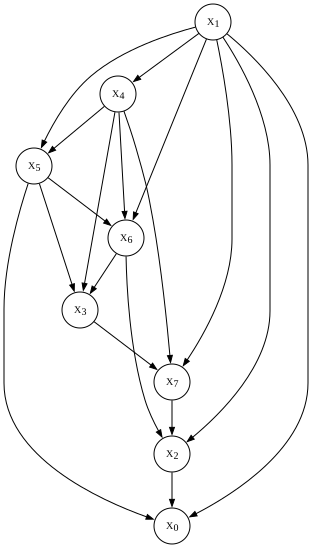

In [6]:
N_NODES = 8
CARDINALITY = 2
ALPHA = 1.0

MAX_IN_DEGREE = 3
MAX_DENSITY = 0.8

dag = gen_dag_indegree(
    n=N_NODES,
    k=MAX_IN_DEGREE,
    seed=123
)

dot = graphviz.Digraph(
    graph_attr={"rankdir": "TB"},
    node_attr={"width": "0.5", "height": "0.5", "fontsize": "10"},
    edge_attr={"arrowsize": "0.7"},
)

for u, v in dag.edges:
    dot.edge(u, v)

for i in range(N_NODES):
    node_id = f"X_{i}"
    dot.node(node_id, label=f"<X<SUB>{i}</SUB>>")

dot

### Ground Truth CPTs
Populate ground-truth CPTs from Dirichlet

In [7]:
def gen_CPTs(G, card, alpha, seed):

    rng = np.random.default_rng(seed)
    model = DiscreteBayesianNetwork(list(G.edges()))
    model.add_nodes_from(G.nodes())

    cpds = []
    for node in G.nodes():
        parents = sorted(G.predecessors(node))
        n_configs = card ** len(parents)
        vals = rng.dirichlet([alpha] * card, size=n_configs).T   # (card, n_configs)
        cpd = TabularCPD(
            variable=node, variable_card=card, values=vals,
            evidence=parents or None,
            evidence_card=[card] * len(parents) or None,
            state_names={v: list(range(card)) for v in [node] + parents},
        )
        cpds.append(cpd)

    model.add_cpds(*cpds)
    model.check_model()
    return model


#### Test

In [8]:
ground_truth = gen_CPTs(G=dag, card=CARDINALITY, alpha=ALPHA, seed=456)

for cpd in ground_truth.get_cpds():
    print(f"{cpd} \n")

+--------+----------+
| X_1(0) | 0.538859 |
+--------+----------+
| X_1(1) | 0.461141 |
+--------+----------+ 

+--------+---------------------+----------------------+
| X_1    | X_1(0)              | X_1(1)               |
+--------+---------------------+----------------------+
| X_4(0) | 0.32406706937795593 | 0.981314983195667    |
+--------+---------------------+----------------------+
| X_4(1) | 0.6759329306220442  | 0.018685016804333033 |
+--------+---------------------+----------------------+ 

+--------+---------------------+-----+---------------------+
| X_1    | X_1(0)              | ... | X_1(1)              |
+--------+---------------------+-----+---------------------+
| X_4    | X_4(0)              | ... | X_4(1)              |
+--------+---------------------+-----+---------------------+
| X_5(0) | 0.06863164792155352 | ... | 0.5398787090259637  |
+--------+---------------------+-----+---------------------+
| X_5(1) | 0.9313683520784465  | ... | 0.46012129097403637 |
+-----

### Evaluation Functions

In [9]:
EPS = 1e-12


def cpd_probs(cpd, test_data):
    """P(node | pa) for every row, using the CPD's own parent order -> (N, card)."""
    parents = list(cpd.variables[1:])
    values = cpd.get_values()                       # (card, n_configs)
    if not parents:
        return np.repeat(values.T, len(test_data), axis=0)
    cols = test_data[parents].to_numpy().astype(np.int64).T
    idx = np.ravel_multi_index(cols, list(cpd.cardinality[1:]))
    return values[:, idx].T

def nn_probs(net_and_parents, test_data, card):
    """Q(node | pa) for every row, from that node's network -> (N, card)."""
    import torch
    net, parents = net_and_parents
    if parents:
        idx = torch.as_tensor(test_data[parents].to_numpy().astype(np.int64), device=DEVICE)
        x = torch.nn.functional.one_hot(idx, card).reshape(len(test_data), -1).float()
    else:
        x = torch.zeros((len(test_data), 1), dtype=torch.float32, device=DEVICE)
    net.eval()
    with torch.no_grad():
        return torch.softmax(net(x), dim=1).cpu().numpy()


def kl_calculation(true_model, test_data, q_probs):
    """MC estimate of D_KL(P* || Q), decomposed by node.

    q_probs : (node, test_data) -> (N, card) array of Q(X_i | pa_i) per row.
    Returns (total, se, per_node, n_zero_mass).
    """
    rows = np.zeros(len(test_data))

    for cpd in true_model.get_cpds():
        node = cpd.variable
        p = cpd_probs(cpd, test_data)
        q = q_probs(node, test_data)

        if np.isnan(q).any():
            raise ValueError(f"Q has NaN for node {node} (unseen parent config?)")

        k = (p * (np.log(np.clip(p, EPS, None)) - np.log(np.clip(q, EPS, None)))).sum(axis=1)
        rows += k

    n = len(rows)
    return float(rows.mean()), float(rows.std(ddof=1) / np.sqrt(n))

def kl_mle(true_model, mle_model, test_data):
    return kl_calculation(
        true_model, test_data,
        q_probs=lambda node, td: cpd_probs(mle_model.get_cpds(node), td),
    )


def kl_nn(true_model, nets, test_data, card):
    return kl_calculation(
        true_model, test_data,
        q_probs=lambda node, td: nn_probs(nets[node], td, card),
    )

In [10]:
'''
def logprob(model, data):
    return np.array([
        np.log(model.get_state_probability(dict(row)))
        for _, row in data.iterrows()
    ])

def logprob_fast(model, data):
    total = np.zeros(len(data))
    for cpd in model.get_cpds():
        node = cpd.variable
        parents = cpd.variables[1:]
        vals = cpd.get_values()
        row = data[node].to_numpy().astype(int)
        if parents:
            col = np.ravel_multi_index(data[parents].to_numpy().astype(int).T, cpd.cardinality[1:])
        else:
            col = 0
        total += np.log(np.clip(vals[row, col], 1e-12, 1.0))
    return total

def neural_logprob(nn_models, G, data, card):
    total = np.zeros(len(data))
    for node in G.nodes():
        parents = sorted(G.predecessors(node))
        X = one_hot(data, parents, card)
        y = data[node].to_numpy().astype(int)
        with torch.no_grad():
            probs = torch.softmax(nn_models[node](X), dim=1).numpy()
        total += np.log(np.clip(probs[np.arange(len(data)), y], 1e-12, 1))
    return total

#KL estimated on held-out test set

def kl_divergence(true_cpd, learned_cpd, test_data):
    # D(P* || P^) = E_{x~P*}[ log P*(x) - log P^(x) ]
    # estimated on held-out test set

    logp_true = logprob_fast(true_cpd, test_data)
    logp_learned = logprob_fast(learned_cpd, test_data)

    pointwise = logp_true - logp_learned
    return pointwise.mean(), pointwise.std() / np.sqrt(len(pointwise))

'''

def mle_param_stats(model):
    
    nodes = list(model.nodes())
    stats = {}
    for nd in nodes:
        vals = model.get_cpds(nd).get_values()      # (card, n_parent_configs)
        card, n_configs = vals.shape
        stats[nd] = {
            "stored_params": int(card * n_configs),
            "free_params":   int((card - 1) * n_configs),
            "memory_bytes":  int(vals.nbytes),
        }

    out = {f"{k}": sum(s[k] for s in stats.values())
           for k in ("stored_params", "free_params", "memory_bytes")}
    out["memory_bytes_native"] = out["memory_bytes"]
    return out

   
def timed_fit(fit_fn, *args, **kwargs):
    """Run fit_fn(*args, **kwargs), returning (model, fit_time_s, rss_delta_bytes).

    rss_delta is only meaningful averaged over repeats and is noisy; the
    analytical/nbytes parameter curve is the precise memory evidence.
    """
    rss_before = None
    proc = psutil.Process(os.getpid())
    rss_before = proc.memory_info().rss

    t0 = time.perf_counter()
    model = fit_fn(*args, **kwargs)
    fit_time = time.perf_counter() - t0

    rss_delta = proc.memory_info().rss - rss_before
    return model, fit_time, rss_delta


### MLE


In [11]:
# MLE with normal default for unseen parent configurations
def fit_mle(G, data, card):
    model = DiscreteBayesianNetwork(list(G.edges()))
    model.add_nodes_from(G.nodes())

    estimator = DiscreteMLE()
    # force full state space so unobserved states aren't dropped
    estimator.state_names = {v: list(range(card)) for v in G.nodes()}
    model.fit(data, estimator=estimator)
    return model

# MLE with a small symmetric Dirichlet pseudocount
def fit_mle_pseudocount(G, data, card):
    pseudo_count=0.5
    m = DiscreteBayesianNetwork(list(G.edges()))
    m.add_nodes_from(G.nodes())
    est = DiscreteBayesianEstimator(
        state_names={v: list(range(card)) for v in G.nodes()},
        prior_type="dirichlet",
        pseudo_counts=float(pseudo_count),   # 0.1–1.0 is a sensible range
    )
    m.fit(data, estimator=est)
    return m


#### Test


In [12]:
N, CARD, ALPHA = 2000, 2, 1.0

G = gen_dag_indegree(n=8, k=3, seed=123)
n = G.number_of_nodes()

print(f"Max in-degree = {3}")
print(f"\nDensity: {G.number_of_edges() / (n*(n-1)/2):.3f}")
print("In-degrees:", dict(sorted(G.in_degree(), key=lambda kv: kv[0])))

ground_truth = gen_CPTs(G=G, card=CARDINALITY, alpha=ALPHA, seed=456)

# sample
data = ground_truth.simulate(n_samples=N, seed=3, show_progress=False)
test_data = ground_truth.simulate(n_samples=N, seed=4, show_progress=False)
print(f"\nSampled {len(data)} rows")

# parameter estimation
mle_model = fit_mle(G, data, CARD)

kl, se = kl_mle(ground_truth, mle_model, test_data)
print(f"KL = {kl:>10.4f}")

Max in-degree = 3

Density: 0.643
In-degrees: {'X_0': 3, 'X_1': 0, 'X_2': 3, 'X_3': 3, 'X_4': 1, 'X_5': 2, 'X_6': 3, 'X_7': 3}


c:\Users\Kaylin\Documents\Neural-Discrete-Bayesian-Network\.venv\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (



Sampled 2000 rows
KL =     0.0149


## Neural Network CPDs

In [13]:


# Linear Softmax Baseline
class NodeNN(nn.Module):
    # one-hot parent config -> softmax distribution over child states
    def __init__(self, n_parents, card, hidden_dims=(), activation=nn.ReLU, dropout=0.0):
        super().__init__()
        in_dim = n_parents * card if n_parents>0 else 1
        dims = [in_dim] + list(hidden_dims)

        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if activation is not None:
                layers.append(activation())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        self.feature_extractor = nn.Sequential(*layers) if layers else nn.Identity()
        self.logits_out = nn.Linear(dims[-1], card)

    def forward(self, x):
        return self.logits_out(self.feature_extractor(x))   # raw logits


def one_hot_parents(data, parents, card):
    if not parents:
        return torch.zeros(len(data), 1, dtype=torch.float32, device=DEVICE)
    idx = torch.as_tensor(data[parents].to_numpy(np.int64), device=DEVICE)
    return torch.nn.functional.one_hot(idx, card).flatten(1).float()

from dataclasses import dataclass, field


@dataclass
class NeuralCPDs:
    """Per-node neural CPDs over a fixed DAG.

    Indexing yields (net, parents) — exactly what nn_probs unpacks — so this
    passes straight to kl_nn. Trailing-underscore fields are fitted attributes.
    """
    models: dict                  # node -> NodeNN
    parents: dict                 # node -> list[str], canonical ordering
    card: int

    best_val_:   dict = field(default_factory=dict)
    train_nll_:  dict = field(default_factory=dict)
    train_time_: dict = field(default_factory=dict)
    stop_epoch_: dict = field(default_factory=dict)

    def __getitem__(self, node):
        return self.models[node], self.parents[node]

    def nodes(self):
        return list(self.models)

    def param_stats(self):
        stored = sum(p.numel() for m in self.models.values() for p in m.parameters())
        native = sum(p.numel() * p.element_size()
                     for m in self.models.values() for p in m.parameters())
        return {
            "stored_params": int(stored),
            "free_params":   int(stored),       # every NN parameter is free
            "memory_bytes":  int(stored * 8),   # float64-equivalent, comparable to CPTs
            "memory_bytes_native": int(native),
        }


def split_train_val(data, val_frac=0.2, seed=0):
    """Hold out a validation subset used only for early stopping."""
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(data))
    n_val = max(1, round(val_frac * len(data)))
    val_idx, train_idx = np.split(perm, [n_val])
    return (data.iloc[train_idx].reset_index(drop=True),
            data.iloc[val_idx].reset_index(drop=True))

def train_nn_cpds(G, df_train, df_val, card,
                  hidden_dims, activation,
                  n_epochs=500, lr=1e-3, dropout=0.0,
                  weight_decay=1e-4, batch_size=64, patience=20,
                  seed=0, verbose=False):
    torch.manual_seed(seed)
    nodes = list(G.nodes())
    parents = {node: sorted(G.predecessors(node)) for node in nodes}
    loss = nn.CrossEntropyLoss()

    models, optimizers = {}, {}
    Xtr, ytr, Xva, yva = {}, {}, {}, {}
    train_times = {node: 0.0 for node in nodes}          

    for node in nodes:
        models[node] = NodeNN(len(parents[node]), card, hidden_dims,
                                activation, dropout).to(DEVICE)
        optimizers[node] = torch.optim.Adam(models[node].parameters(),
                                            lr=lr, weight_decay=weight_decay)
        Xtr[node] = one_hot_parents(df_train, parents[node], card)
        ytr[node] = torch.as_tensor(df_train[node].to_numpy().astype(np.int64),
                                    device=DEVICE)
        Xva[node] = one_hot_parents(df_val, parents[node], card)
        yva[node] = torch.as_tensor(df_val[node].to_numpy().astype(np.int64),
                                    device=DEVICE)
    n_train = len(df_train)
    n_val = len(df_val)

    # Early stopping state
    best_val   = {node: float("inf") for node in nodes}   
    best_state = {node: None for node in nodes}
    patience_ctr = {node: 0 for node in nodes}
    stopped    = {node: False for node in nodes}
    stop_epoch = {node: n_epochs for node in nodes}
    last_train = {node: float("nan") for node in nodes}

    # Training loop
    for epoch in range(n_epochs):
        epoch_train_loss = 0.0
        active_nodes = 0

        for node in nodes:
            if stopped[node]:
                continue

            model, opt = models[node], optimizers[node]

            # TRAIN
            t0 = time.perf_counter()
            model.train()

            # TRAIN
            if batch_size is None:
                opt.zero_grad()
                l = loss(model(Xtr[node]), ytr[node])
                l.backward()
                opt.step()
                last_train[node] = l.item()
            else:
                perm = torch.randperm(n_train, device=DEVICE)
                running = 0.0
                for s in range(0, n_train, batch_size):
                    b = perm[s:s + batch_size]
                    opt.zero_grad()
                    l = loss(model(Xtr[node][b]), ytr[node][b])
                    l.backward()
                    opt.step()
                    running += l.item() * len(b)
                last_train[node] = running / n_train
            train_times[node] += time.perf_counter() - t0

            epoch_train_loss += last_train[node]
            active_nodes += 1

            # VALIDATION
            model.eval()
            with torch.no_grad():
                val_loss = loss(model(Xva[node]), yva[node]).item()

            # EARLY STOPPING
            if val_loss < best_val[node] - 1e-6:
                best_val[node] = val_loss
                patience_ctr[node] = 0
                best_state[node] = {k: v.detach().clone()
                                    for k, v in model.state_dict().items()}
            else:
                patience_ctr[node] += 1
                if patience_ctr[node] >= patience:
                    stopped[node] = True
                    stop_epoch[node] = epoch + 1
                    model.load_state_dict(best_state[node])
                    if verbose:
                        print(f"Node {node} early stopped at epoch {epoch+1}. Best val loss={best_val[node]:.4f}")

        if verbose and (epoch + 1) % 50 == 0 and active_nodes > 0:
            print(f"Epoch {epoch+1}, Avg Train Loss: {epoch_train_loss / active_nodes:.4f}")

        if verbose and all(stopped.values()):
            print(f"All nodes early-stopped at epoch {epoch+1}.")
            break

    for node in nodes:
        if not stopped[node] and best_state[node] is not None:
            models[node].load_state_dict(best_state[node])

    return NeuralCPDs(
        models=models, parents=parents, card=card,
        best_val_=best_val, train_nll_=last_train,
        train_time_=train_times, stop_epoch_=stop_epoch,
    )

def fit_nn(G, data, card, val_data=None, val_frac=0.2,
           hidden_dims=(32,), activation=nn.ReLU, seed=0, verbose=False, **kw):
    """Neural CPD estimator. Mirrors fit_mle(G, data, card).

    val_data : held-out split for early stopping. If None, carved from `data`
               — convenient for standalone use, but note that then `data` is a
               budget rather than the rows actually fitted.
    """
    if val_data is None:
        data, val_data = split_train_val(data, val_frac=val_frac, seed=seed)
    return train_nn_cpds(G, data, val_data, card,
                         hidden_dims=hidden_dims, activation=activation,
                         seed=seed, verbose=verbose, **kw)

#### Test


In [14]:
# ── Smoke test: NN CPDs run end to end ───────────────────────────────────────
G = gen_dag_indegree(n=5, k=2, seed=0)
true_model = gen_CPTs(G, CARD, alpha=1.0, seed=1)

data = true_model.simulate(n_samples=1000, seed=2, show_progress=False)
test_data = true_model.simulate(n_samples=2000, seed=3, show_progress=False)
train_df, val_df = split_train_val(data, val_frac=0.2, seed=0)

mle = fit_mle(G, train_df, CARD)
nn_model = fit_nn(G, train_df, CARD, val_data=val_df, n_epochs=100, verbose=True)

kl_m, _ = kl_mle(true_model, mle, test_data)
kl_n, _ = kl_nn(true_model, nn_model, test_data, CARD)

# probabilities are valid
q = nn_probs(nn_model["X_0"], test_data, CARD)
assert q.shape == (len(test_data), CARD)
assert np.allclose(q.sum(axis=1), 1.0)

print(f"KL  MLE {kl_m:.4f}   NN {kl_n:.4f}")
print(f"params  MLE {mle_param_stats(mle)['stored_params']}"
      f"   NN {nn_model.param_stats()['stored_params']}")


C:\Users\Kaylin\AppData\Local\Temp\ipykernel_22960\743806726.py:26: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  idx = torch.as_tensor(data[parents].to_numpy(np.int64), device=DEVICE)


Node X_2 early stopped at epoch 35. Best val loss=0.4815
Node X_3 early stopped at epoch 45. Best val loss=0.4700
Node X_4 early stopped at epoch 49. Best val loss=0.5113
Epoch 50, Avg Train Loss: 0.4330
Epoch 100, Avg Train Loss: 0.4312
KL  MLE 0.0252   NN 0.0101
params  MLE 30   NN 970


## Experiments

In [15]:
def config_exists(df, estimator, dag, n_nodes, in_deg, alpha, sample_size):
    if df.empty or "estimator" not in df.columns:
        return False
    return (
        (df["estimator"]   == estimator) &
        (df["dag_idx"] == dag) &
        (df["n_nodes"] == n_nodes) &
        (df["in_degree"] == in_deg) &
        (df["alpha"] == alpha) &
        (df["sample_size"] == sample_size)
    ).any()

def flush(records, path):
    if not records:
        return
    pd.DataFrame(records).to_csv(path, mode="a",
                                 header=not os.path.exists(path), index=False)
    records.clear()

In [20]:
# experiment configs

NODE_COUNTS  = [5, 10, 15, 20]#, 30, 40]
IN_DEGREES   = [2, 4, 6, 8, 10] # max_in_degree
ALPHAS       = [0.1, 0.5]#, 1.0] # sparse/peaked -> flat/uniform
SIM          = 5 # random DAGs per config

CARD         = 2
SAMPLE_SIZES     = [600, 1000, 1400] #train+val
VAL_FRAC     = 0.2
N_TEST           = 10000
N_EPOCHS         = 200

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
RESULTS_CSV = os.path.join(RESULTS_DIR, "results.csv")

ESTIMATORS = [
    {"name": "mle",           "type": "mle"},
    {"name": "mle_dirichlet", "type": "mle_pseudo"},
    {"name": "nn_linear",     "type": "nn", "hidden_dims": (),    "activation": None},
    {"name": "nn_32_relu",    "type": "nn", "hidden_dims": (32,), "activation": nn.ReLU},
]

In [22]:
import csv, shutil

shutil.copy(RESULTS_CSV, RESULTS_CSV + ".bak")
NEW_COLS = ["stop_epoch_mean", "frac_at_ceiling"]

with open(RESULTS_CSV, newline="") as f:
    rows = [r for r in csv.reader(f) if r]

header, body = rows[0], rows[1:]
width = max(len(r) for r in body)
print("header:", len(header), "| widest row:", width)
print("last 4 header cols:", header[-4:])
assert width - len(header) == len(NEW_COLS), "column delta is not what we assumed"

header = header + NEW_COLS
body = [r + [""] * (width - len(r)) for r in body]

with open(RESULTS_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(header)
    w.writerows(body)

fixed = pd.read_csv(RESULTS_CSV)
print(fixed.shape, "|", fixed["frac_at_ceiling"].notna().sum(), "rows have the new columns")

header: 18 | widest row: 20
last 4 header cols: ['stored_params', 'free_params', 'memory_bytes', 'memory_bytes_native']
(3036, 20) | 1386 rows have the new columns


In [23]:
experiment_configs = [(n, k, a) for n in NODE_COUNTS for k in IN_DEGREES for a in ALPHAS]

# experiment loop
plot_records = []   # (n_nodes, density, in_degree, kl, sample_size)
existing_df = pd.read_csv(RESULTS_CSV) if os.path.exists(RESULTS_CSV) else pd.DataFrame()

for n_nodes, in_deg, alpha in tqdm(experiment_configs, desc="configs"):
    dag_base_dir = os.path.join(RESULTS_DIR, "data", f"alpha_{alpha}",
                                f"BN_{n_nodes}", f"indegree_{in_deg}")
    os.makedirs(dag_base_dir, exist_ok=True)

    for dag in range(1, SIM + 1):

        todo = [(est, s) for est in ESTIMATORS for s in SAMPLE_SIZES
                if not config_exists(existing_df, est["name"], dag,
                                     n_nodes, in_deg, alpha, s)]
        if not todo:
            continue

        seed = 1000 * dag + 10 * in_deg + n_nodes
        G = gen_dag_indegree(n_nodes, in_deg, seed=seed)
        true_model = gen_CPTs(G, CARD, alpha, seed=seed + 1)

        dag_dir = os.path.join(dag_base_dir, f"dag_{dag}")
        os.makedirs(dag_dir, exist_ok=True)

        # actual density of this realised graph
        max_possible = n_nodes * (n_nodes - 1) / 2
        density = G.number_of_edges() / max_possible if max_possible > 0 else 0

        # Generate train & test data ONCE per DAG, outside the sample-size loop
 
        train_path = os.path.join(dag_dir, "train.csv")
        test_path  = os.path.join(dag_dir, "test.csv")

        if os.path.exists(train_path):
            data = pd.read_csv(train_path)
        else:
            data = true_model.simulate(n_samples=max(SAMPLE_SIZES), seed=seed,
                                       show_progress=False)
            data.to_csv(train_path, index=False)

        if os.path.exists(test_path):
            test_data = pd.read_csv(test_path)
        else:
            test_data = true_model.simulate(n_samples=N_TEST, seed=seed + 9999,
                                            show_progress=False)
            test_data.to_csv(test_path, index=False)


        for samples in SAMPLE_SIZES:

            sample = data.iloc[:samples]
            train_df, val_df = split_train_val(sample, val_frac=VAL_FRAC, seed=seed)
            n_fit = len(train_df)

            for est in ESTIMATORS:
                if config_exists(existing_df, est["name"], dag,
                                 n_nodes, in_deg, alpha, samples):
                    continue

                if est["type"] == "mle":
                    model, fit_time, rss = timed_fit(fit_mle, G, train_df, CARD)
                elif est["type"] == "mle_pseudo":
                    model, fit_time, rss = timed_fit(fit_mle_pseudocount, G, train_df, CARD)
                else:
                    model, fit_time, rss = timed_fit(
                        fit_nn, G, train_df, CARD,
                        val_data=val_df,
                        hidden_dims=est["hidden_dims"],
                        activation=est["activation"],
                        n_epochs=N_EPOCHS,
                        seed=seed + samples,
                    )

                if isinstance(model, NeuralCPDs):
                    kl, se = kl_nn(true_model, model, test_data, CARD)
                    extra = model.param_stats()
                    extra["stop_epoch_mean"] = float(np.mean(list(model.stop_epoch_.values())))
                    extra["frac_at_ceiling"] = float(np.mean(
                        [e >= N_EPOCHS for e in model.stop_epoch_.values()]))
                else:
                    kl, se = kl_mle(true_model, model, test_data)
                    extra = mle_param_stats(model)

                plot_records.append({
                    "estimator":   est["name"],
                    "hidden_dims": str(list(est.get("hidden_dims", []))) if est["type"] == "nn" else "",
                    "activation":  ("" if est["type"] != "nn"
                                    else ("linear" if est["activation"] is None
                                          else est["activation"].__name__)),
                    "dag_idx":     dag,
                    "n_nodes":     n_nodes,
                    "in_degree":   in_deg,
                    "alpha":       alpha,
                    "sample_size": samples,     # budget
                    "n_fit":       n_fit,       # rows actually fitted
                    "density":     density,
                    "kl":          kl,
                    "kl_se":       se,
                    "fit_time_s":  fit_time,
                    "fit_rss_delta_bytes": rss,   # unreliable for NN rows
                    **extra,
                })

        flush(plot_records, RESULTS_CSV)



configs:   0%|          | 0/40 [00:00<?, ?it/s]

configs:  85%|████████▌ | 34/40 [00:56<00:10,  1.67s/it]


KeyboardInterrupt: 

### Plotting functions

In [ ]:
"""
RQ1 plotting — single-variable-at-a-time design (no density parameter).

Every plot fixes all experimental variables except x and hue.
Change the DEFAULT_* constants below to control which slice you're viewing.
"""

import numpy as np
import matplotlib.pyplot as plt

# ── Defaults: the "held constant" values for each variable ───────────────────

DEFAULT_SAMPLE_SIZE  = 1000
DEFAULT_ALPHA        = 0.5
DEFAULT_N_NODES      = 20
DEFAULT_IN_DEGREE    = 4
DEFAULT_ESTIMATOR    ="mle"

# ── Palette ──────────────────────────────────────────────────────────────────

_PALETTE = ["#2563eb", "#e11d48", "#16a34a", "#d97706",
            "#7c3aed", "#0891b2", "#be185d", "#4d7c0f"]


def _colors(n):
    if n <= len(_PALETTE):
        return _PALETTE[:n]
    cmap = plt.get_cmap("viridis")
    return [cmap(i / max(n - 1, 1)) for i in range(n)]


# ── Core filter helper ──────────────────────────────────────────────────────

def _filter(df, x, hue, alpha=None, sample_size=None,
            n_nodes=None, in_degree=None, estimator=None):
    """Filter df to fixed values for every variable that isn't x or hue."""
    sub = df.copy()
    skip = {x, hue}

    if "sample_size" not in skip and sample_size is not None:
        sub = sub[sub["sample_size"] == sample_size]

    if "alpha" not in skip and alpha is not None:
        sub = sub[sub["alpha"] == alpha]

    if "n_nodes" not in skip and n_nodes is not None:
        sub = sub[sub["n_nodes"] == n_nodes]

    if "in_degree" not in skip and in_degree is not None:
        sub = sub[sub["in_degree"] == in_degree]

    if "estimator" not in skip and estimator is not None:
        sub = sub[sub["estimator"] == estimator]

    return sub


# ── Main plotting function ──────────────────────────────────────────────────

def plot_grouped_curves(
    df, x, hue, y="kl",
    # fixed-variable overrides (None → use DEFAULT_*)
    alpha=None, sample_size=None,
    n_nodes=None, in_degree=None, estimator=None
    # plot styling
    logy=False, err=None, min_obs=3,
    xlabel=None, ylabel=None, title=None, hue_label=None,
    out_path=None, ax=None, figsize=(7, 5),
):
    """Mean y vs x, one curve per hue value, all other variables held fixed."""
    if alpha is None:        alpha = DEFAULT_ALPHA
    if sample_size is None:  sample_size = DEFAULT_SAMPLE_SIZE
    if n_nodes is None:      n_nodes = DEFAULT_N_NODES
    if in_degree is None:    in_degree = DEFAULT_IN_DEGREE
    if estimator is None:    estimator = DEFAULT_ESTIMATOR

    sub = _filter(df, x, hue,
                  alpha=alpha, sample_size=sample_size,
                  n_nodes=n_nodes, in_degree=in_degree, estimator=estimator)

    if sub.empty:
        print(f"WARNING: no data after filtering for {x} vs {hue}. "
              f"Check your default values.")
        return None

    # Build subtitle showing what's held constant
    skip = {x, hue}
    held = []
    if "sample_size" not in skip: held.append(f"N={sample_size}")
    if "alpha"       not in skip: held.append(f"α={alpha}")
    if "n_nodes"     not in skip: held.append(f"nodes={n_nodes}")
    if "in_degree"   not in skip: held.append(f"k={in_degree}")
    if "estimator"   not in skip: held.append(f"est={estimator}")
    held_str = ",  ".join(held)

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize)

    hue_vals = sorted(sub[hue].dropna().unique())
    colors = _colors(len(hue_vals))

    for hv, c in zip(hue_vals, colors):
        s = sub[sub[hue] == hv]
        g = s.groupby(x)[y].agg(["mean", "std", "sem", "count"]).reset_index()
        g = g[g["count"] >= min_obs]
        if g.empty:
            continue
        label = f"{hue_label or hue} = {hv}"
        if err in ("std", "sem"):
            ax.errorbar(g[x], g["mean"], yerr=g[err].fillna(0.0), marker="o",
                        lw=2, color=c, label=label, capsize=3, zorder=3)
        else:
            ax.plot(g[x], g["mean"], marker="o", lw=2, color=c,
                    label=label, zorder=3)

    if logy:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel or x, fontsize=12)
    ax.set_ylabel(ylabel or y, fontsize=12)
    if title:
        ax.set_title(f"{title}\n({held_str})", fontsize=12)
    else:
        ax.set_title(held_str, fontsize=11, color="grey")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

    if own_fig:
        fig.tight_layout()
        if out_path:
            fig.savefig(out_path, dpi=150)
        return fig, ax
    return ax


# ── Memory plots (unchanged) ────────────────────────────────────────────────

def plot_cardinality_wall(cards=(2, 3, 4, 5), max_k=12,
                          wall_bytes=None, out_path=None,
                          ax=None, figsize=(7, 5)):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize)

    ks = np.arange(0, max_k + 1)
    for c, col in zip(cards, _colors(len(cards))):
        ax.plot(ks, [8 * c ** (k + 1) for k in ks], marker="o", lw=2,
                color=col, label=f"card = {c}")

    if wall_bytes:
        ax.axhline(wall_bytes, color="black", ls=":", lw=1.5,
                   label=f"{wall_bytes/1024**3:.0f} GB wall")

    ax.set_yscale("log")
    ax.set_xlabel("Parent in-degree $k$", fontsize=12)
    ax.set_ylabel("CPT memory (bytes, log)", fontsize=12)
    ax.set_title("Storage cost by cardinality: reaching the memory wall",
                 fontsize=12)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

    if own_fig:
        fig.tight_layout()
        if out_path:
            fig.savefig(out_path, dpi=150)
        return fig, ax
    return ax


(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'Storage cost by cardinality: reaching the memory wall'}, xlabel='Parent in-degree $k$', ylabel='CPT memory (bytes, log)'>)

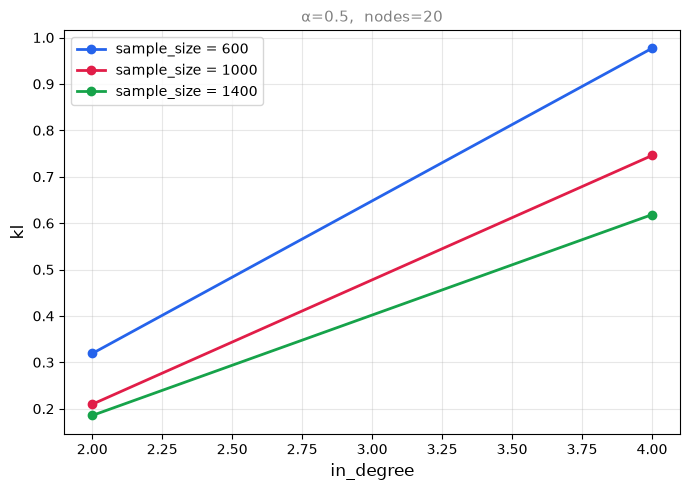

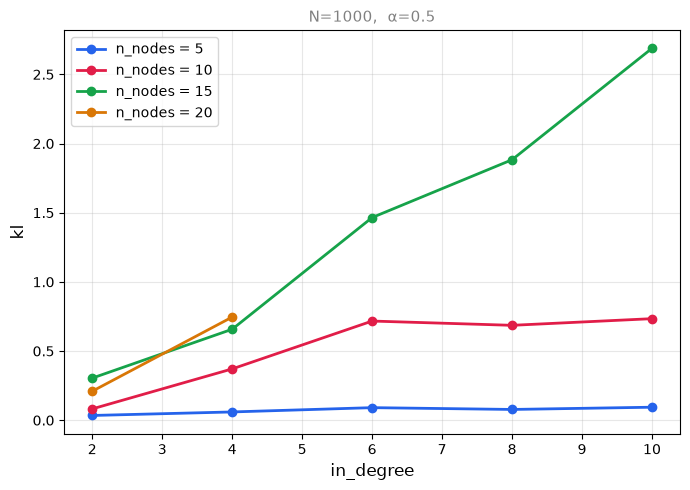

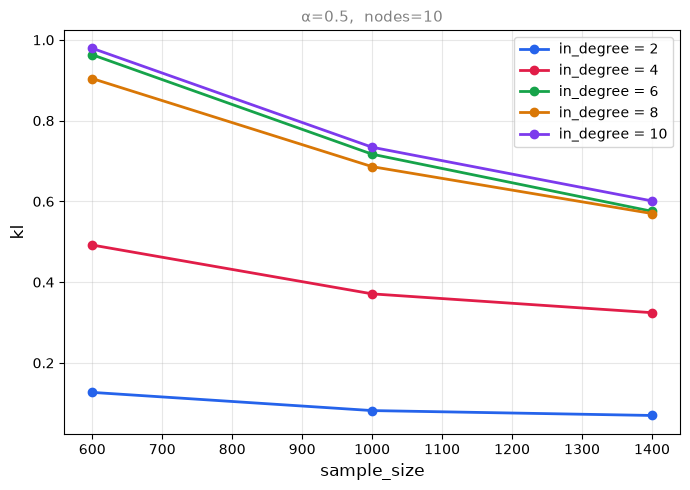

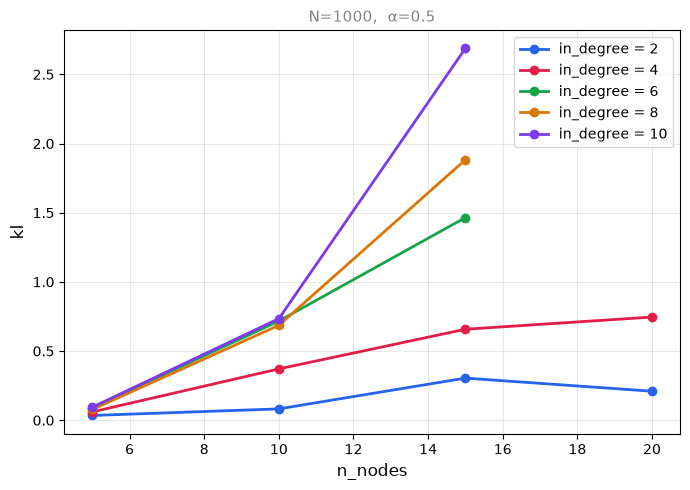

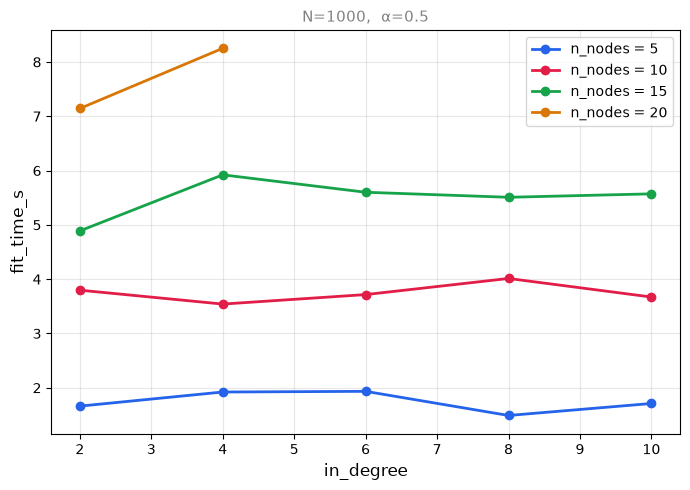

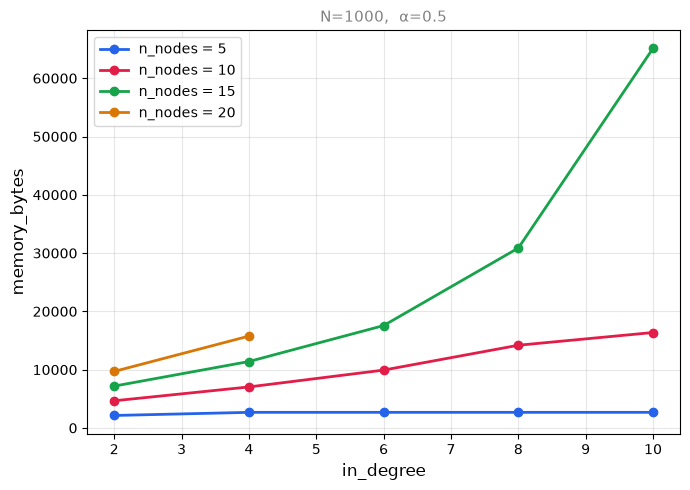

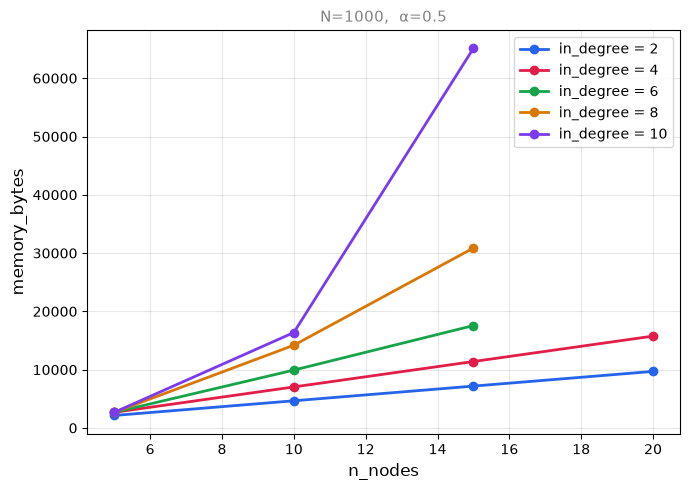

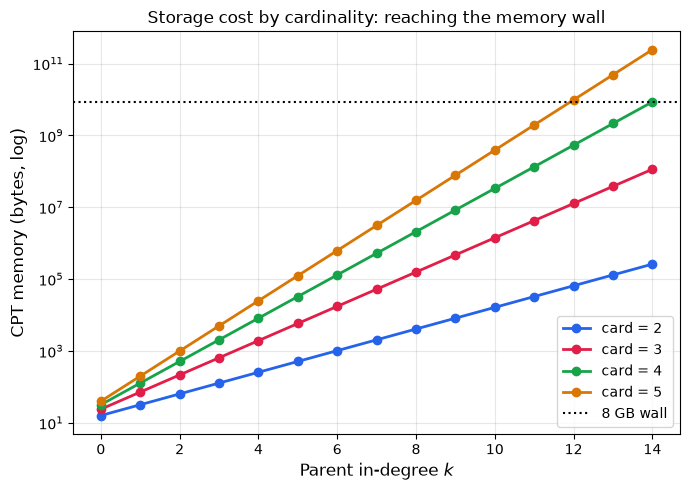

In [26]:
df = pd.read_csv(f"{RESULTS_DIR}/results.csv")

plot_dir = os.path.join(RESULTS_DIR, "plots")
os.makedirs(plot_dir, exist_ok=True)

# (1)  KL vs in-degree, one curve per sample size
plot_grouped_curves(df, x="in_degree", hue="sample_size", y="kl", out_path="kl_vs_indegree_by_samplesize.png")
# (1b) same, grouped by network size
plot_grouped_curves(df, x="in_degree", hue="n_nodes", y="kl", out_path="kl_vs_indegree_by_n_nodes.png")
# (3)  KL vs sample size, one curve per in-degree
plot_grouped_curves(df, x="sample_size", hue="in_degree", y="kl", n_nodes=10, out_path="kl_vs_samplesize.png")
# (3b) KL vs network size, one curve per in-degree
plot_grouped_curves(df, x="n_nodes", hue="in_degree", y="kl", out_path="kl_vs_networksize.png")
# (5)  training time — turn OFF log-y since it's seconds, not divergence
plot_grouped_curves(df, x="in_degree", hue="n_nodes", y="fit_time_s", logy=False, out_path="training_time.png")
# (2)  memory vs in-degree with analytical overlay
plot_grouped_curves(df, x="in_degree", hue="n_nodes", y="memory_bytes", out_path="memory_vs_indegree")
# (2)  memory vs in-degree with analytical overlay
plot_grouped_curves(df, x="n_nodes", hue="in_degree", y="memory_bytes", out_path="memory_vs_n_nodes")
# (4)  cardinality wall
plot_cardinality_wall(cards=(2,3,4,5), max_k=14, wall_bytes=8*1024**3, out_path="fig4.png")

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'N=1000,  α=0.5,  nodes=20'}, xlabel='in_degree', ylabel='stored_params'>)

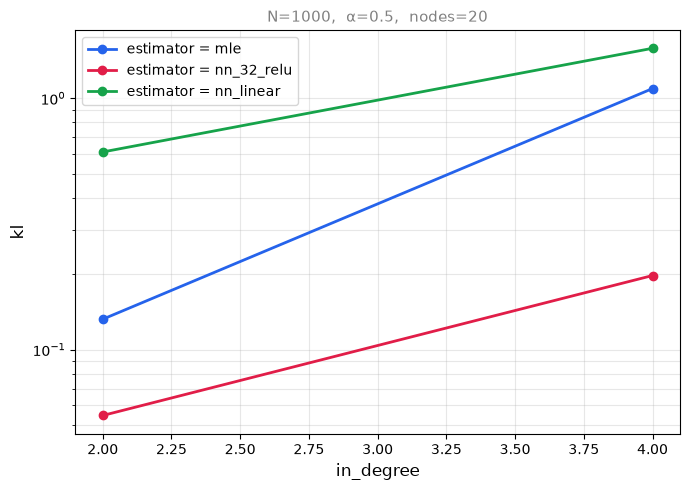

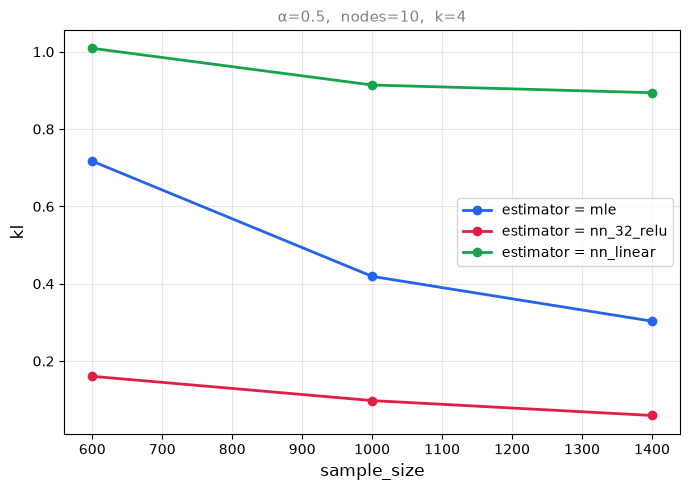

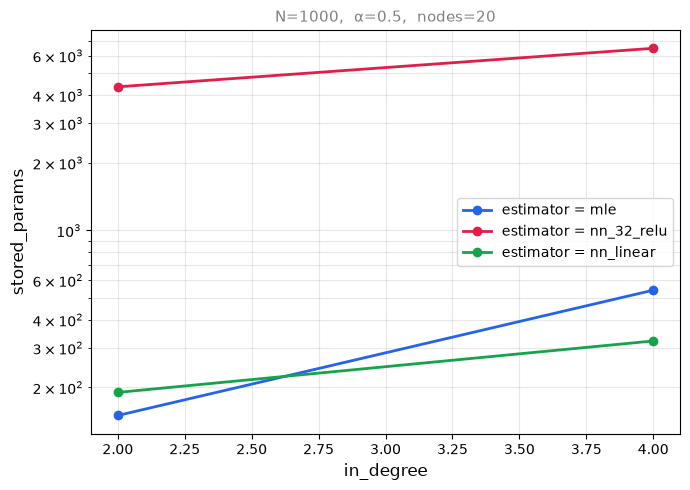

In [30]:
plot_grouped_curves(df, x="in_degree",   hue="estimator", y="kl", logy=True)
plot_grouped_curves(df, x="sample_size", hue="estimator", y="kl", n_nodes=10)
plot_grouped_curves(df, x="in_degree",   hue="estimator", y="stored_params", logy=True)